# Clase 23: Valuación de opciones americanas con Box-Ross-Rubinstein

> **Objetivo:** Entender por qué las opciones americanas no tienen solución analítica cerrada, construir el árbol binomial de Cox-Ross-Rubinstein (CRR), e implementar el algoritmo de ejercicio anticipado óptimo para calcular el precio de una opción americana.
> 

---

## 1. ¿Qué hace diferente a una opción americana?

Una opción **europea** solo puede ejercerse al vencimiento. Una opción **americana** puede ejercerse en cualquier momento antes o al vencimiento.

Esa flexibilidad adicional tiene valor. una opción americana siempre vale al menos lo que la europea equivalente. Pero esa misma flexibilidad hace que no exista una fórmula cerrada como Black-Scholes: hay que evaluar en cada punto del tiempo si conviene ejercer ahora o esperar.

La pregunta que el modelo debe responder en cada nodo es:

$$
V_{\text{americano}} = \max(\text{valor intrínseco},\ \text{valor de continuar})
$$

---

## 2. El árbol binomial de Cox-Ross-Rubinstein

En lugar de simular trayectorias continuas, discretizamos el tiempo en N pasos. En cada paso, el precio puede subir por un factor u o bajar por un factor d. Esto crea un árbol de precios posibles  y podemos recorrerlo hacia atrás para encontrar el valor de la opción en cada nodo.

### Parámetros del árbol

Dado un tiempo total T dividido en N pasos de tamaño $\Delta t = T/N$:

$$
u = e^{\sigma\sqrt{\Delta t}}, \qquad d = \frac{1}{u} = e^{-\sigma\sqrt{\Delta t}}
$$

$$
p = \frac{e^{r \Delta t} - d}{u - d}
$$

Donde p es la **probabilidad neutral al riesgo** de una subida. No es la probabilidad real, es la probabilidad que hace que el árbol sea consistente con no-arbitraje.

## 3. Algoritmo

El árbol se construye en dos pasadas:

**Pasada hacia adelante:** construir todos los precios posibles al vencimiento.

**Pasada hacia atrás:** calcular el valor de la opción en cada nodo, tomando el máximo entre ejercer ahora (valor intrínseco) y continuar (valor esperado descontado).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def arbol_crr(S0, K, r, T, sigma, N, option='call', style='european'):
    """
    Árbol binomial CRR para opciones europeas o americanas.

    S0     : precio inicial
    K      : strike
    r      : tasa libre de riesgo
    T      : tiempo al vencimiento en años
    sigma  : volatilidad
    N      : número de pasos
    option : 'call' o 'put'
    style  : 'european' o 'american'
    """
    dt = T / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1 / u
    p  = (np.exp(r * dt) - d) / (u - d)
    df = np.exp(-r * dt)   # factor de descuento por paso

    # --- Árbol de precios al vencimiento ---
    # ST[i] = S0 * u^(N-i) * d^i  para i = 0, 1, ..., N
    ST = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])

    # --- Valores de la opción al vencimiento ---
    if option == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    # --- Inducción hacia atrás ---
    for step in range(N-1, -1, -1):
        S_step = np.array([S0 * (u**(step-i)) * (d**i) for i in range(step+1)])

        # Valor de continuar (esperanza descontada)
        V_continuar = df * (p * V[:step+1] + (1-p) * V[1:step+2])

        if style == 'american':
            # Valor de ejercer ahora
            if option == 'call':
                V_ejercer = np.maximum(S_step - K, 0)
            else:
                V_ejercer = np.maximum(K - S_step, 0)
            V = np.maximum(V_continuar, V_ejercer)
        else:
            V = V_continuar

    return V[0]

# Parámetros
S0    = 669.03
K     = 680
r     = 0.042
T     = 31/365
sigma = 0.1687
N     = 100

precio_euro_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'european')
precio_amer_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'american')
precio_euro_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'european')
precio_amer_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'american')

print(f"Call europea  : ${precio_euro_call:.4f}")
print(f"Call americana: ${precio_amer_call:.4f}  (prima por ejercicio anticipado: ${precio_amer_call - precio_euro_call:.4f})")
print(f"Put europea   : ${precio_euro_put:.4f}")
print(f"Put americana : ${precio_amer_put:.4f}  (prima por ejercicio anticipado: ${precio_amer_put - precio_euro_put:.4f})")

Call europea  : $9.3925
Call americana: $9.3925  (prima por ejercicio anticipado: $0.0000)
Put europea   : $17.9412
Put americana : $18.2479  (prima por ejercicio anticipado: $0.3068)


> Para calls sobre activos sin dividendos, el ejercicio anticipado **nunca es óptimo**. la call americana vale lo mismo que la europea. Para puts, el ejercicio anticipado sí puede ser óptimo cuando la opción está muy ITM: vale más tener el efectivo ahora que esperar.
> 

---

## 4. Convergencia: ¿cuántos pasos necesito?

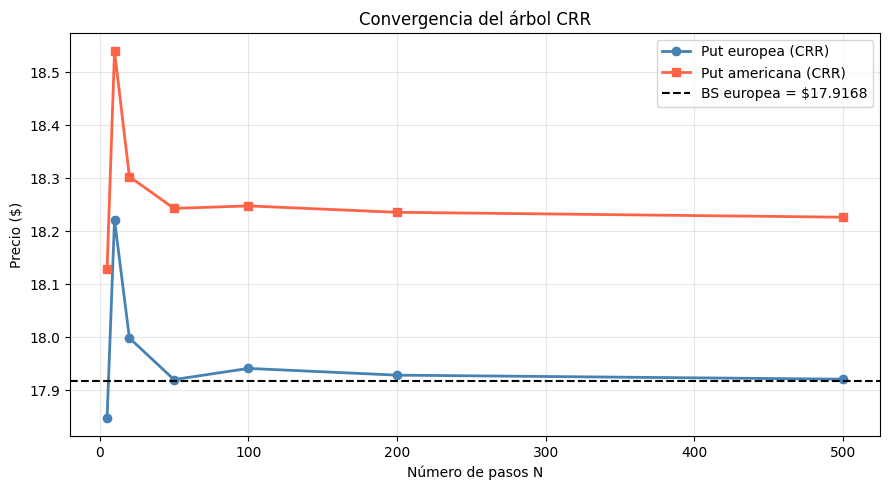

In [2]:
# Precio vs. número de pasos
pasos   = [5, 10, 20, 50, 100, 200, 500]
precios_euro = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'european') for n in pasos]
precios_amer = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'american') for n in pasos]

# Precio BS como referencia
from scipy.stats import norm
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_put = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

plt.figure(figsize=(9, 5))
plt.plot(pasos, precios_euro, marker='o', color='steelblue',
         linewidth=2, label='Put europea (CRR)')
plt.plot(pasos, precios_amer, marker='s', color='tomato',
         linewidth=2, label='Put americana (CRR)')
plt.axhline(bs_put, color='black', linestyle='--',
            label=f'BS europea = ${bs_put:.4f}')
plt.xlabel('Número de pasos N')
plt.ylabel('Precio ($)')
plt.title('Convergencia del árbol CRR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Prima por ejercicio anticipado en función del moneyness

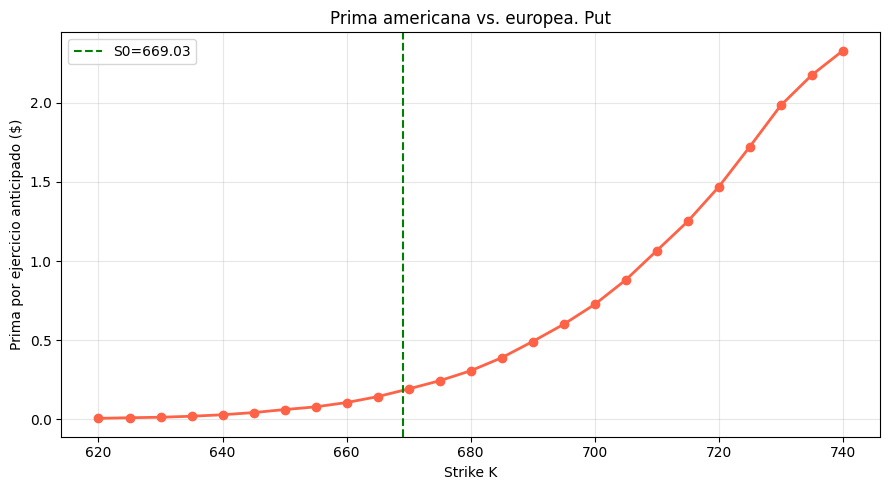

In [3]:
K_range      = np.arange(620, 741, 5)
prima_antic  = []

for k in K_range:
    euro = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'european')
    amer = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'american')
    prima_antic.append(amer - euro)

plt.figure(figsize=(9, 5))
plt.plot(K_range, prima_antic, color='tomato', linewidth=2, marker='o')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Strike K')
plt.ylabel('Prima por ejercicio anticipado ($)')
plt.title('Prima americana vs. europea. Put')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparación CRR vs. Black-Scholes

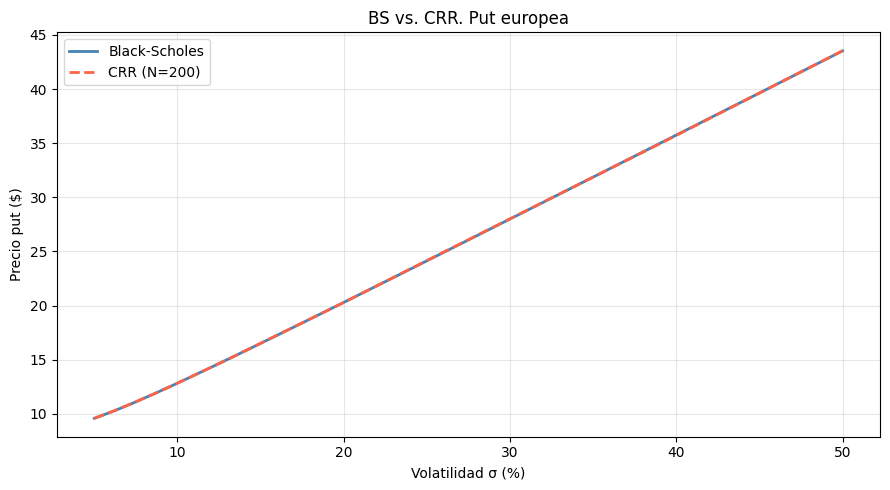

In [4]:
sigma_range  = np.linspace(0.05, 0.50, 40)
bs_precios   = []
crr_precios  = []

for s in sigma_range:
    d1 = (np.log(S0/K) + (r + 0.5*s**2)*T) / (s*np.sqrt(T))
    d2 = d1 - s*np.sqrt(T)
    bs_precios.append(K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1))
    crr_precios.append(arbol_crr(S0, K, r, T, s, 200, 'put', 'european'))

plt.figure(figsize=(9, 5))
plt.plot(sigma_range*100, bs_precios,  color='steelblue', linewidth=2,
         label='Black-Scholes')
plt.plot(sigma_range*100, crr_precios, color='tomato',    linewidth=2,
         linestyle='--', label='CRR (N=200)')
plt.xlabel('Volatilidad σ (%)')
plt.ylabel('Precio put ($)')
plt.title('BS vs. CRR. Put europea')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> Con N suficientemente grande, CRR converge a BS para opciones europeas. La diferencia entre la curva americana y la europea es la prima de ejercicio anticipado.
> 

---

## Preguntas de reflexión

- **¿Por qué el ejercicio anticipado de una call sobre un activo sin dividendos nunca es óptimo? ¿Qué cambia si el activo paga dividendos?** 

*Respuesta:*
Al ejercer una opción call anticipadamente, destruyes su valor temporal (la posibilidad de que la acción siga subiendo) y te obligas a desembolsar el capital del strike ($K$) antes de tiempo, perdiendo los intereses que ese dinero podría generar. Siempre es más rentable vender la opción en el mercado que ejercerla.Si paga dividendos: La acción caerá en la fecha ex-dividendo. Si el dividendo a cobrar es mayor que el valor temporal de la opción y los intereses perdidos por pagar el strike hoy, se vuelve óptimo ejercer justo antes de que se pague el dividendo.

- **En la gráfica de convergencia, ¿por qué el precio oscila antes de converger? ¿Qué relación tiene eso con si N es par o impar?**

*Respuesta:*
La oscilación (efecto diente de sierra) ocurre por la alineación de los nodos finales del árbol respecto al strike ($K$). Cuando el número de pasos ($N$) es par, existe un nodo central que coincide exactamente con el precio spot inicial ($S_0$). Cuando $N$ es impar, los nodos quedan "a horcajadas" (por encima y por debajo) de $S_0$. Esta diferencia de geometría altera cómo se calcula el valor intrínseco en los nodos cercanos a $K$, causando pequeñas sobreestimaciones y subestimaciones que se van mitigando conforme $N$ crece.


- **La prima por ejercicio anticipado es mayor para puts muy ITM. ¿Por qué intuitivamente tiene sentido ejercer anticipadamente una put muy ITM?**

*Respuesta:*
Por el valor del dinero en el tiempo. La ganancia de una put está limitada (lo máximo que puedes ganar es $K$ si la acción cae a cero). Si la put está muy profunda In-The-Money (ITM), el potencial de que la acción caiga mucho más es mínimo. Conviene ejercer inmediatamente para recibir el efectivo del strike ($K$) hoy mismo y ponerlo a invertir a la tasa libre de riesgo ($r$), en lugar de esperar al vencimiento sin generar rendimientos.

- **Si aumentas T de 31 días a 1 año, ¿cómo esperas que cambie la diferencia entre la put americana y la europea? ¿Por qué?**

*Respuesta:*
La diferencia (la prima por ejercicio anticipado) aumentará. Al incrementar el tiempo al vencimiento ($T$), el costo de oportunidad de esperar para cobrar se vuelve mucho mayor. Un año de intereses generados sobre el capital liberado al ejercer temprano es mucho más valioso que solo 31 días de intereses, haciendo que la flexibilidad americana valga más.

- **El árbol CRR usa probabilidades neutrales al riesgo p, no probabilidades reales. ¿Qué significa eso y por qué es válido para el pricing?**

*Respuesta:*
La probabilidad $p$ no intenta predecir la dirección real del mercado. Es una probabilidad matemática construida bajo el supuesto de que a los inversores no les importa el riesgo y todos los activos rinden la tasa libre de riesgo ($r$). Es válido para el pricing gracias al principio de no-arbitraje: debido a que puedes replicar el pago de la opción comprando la acción y pidiendo prestado a la tasa $r$ (cobertura delta), el valor real esperado de la acción se vuelve irrelevante; el precio de la opción depende matemáticamente solo de $r$ y de la volatilidad ($\sigma$).
